In [ ]:
from datasets import load_dataset
import numpy as np
import pandas as pd


In [15]:
ds = load_dataset('imdb')

In [18]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [8]:
train_df = ds['train'].to_pandas();

In [16]:
train_df.sample(5)

,text,label
15121,"""Lion King 1 1/2"" is the funniest non-theatric...",1
17010,This movie is so good I could watch it all day...,1
19040,When I heard that this movie was coming out th...,1
8018,The Rookie suffers from so much. There are the...,0
17828,I thought this was an utterly charming film. T...,1


In [17]:
train_df['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

In [19]:
train_df['sentiment'] = np.where(train_df['label'] == 1, 'positive', 'negative')

In [21]:
train_df.sentiment.value_counts()

sentiment
negative    12500
positive    12500
Name: count, dtype: int64

Matplotlib is building the font cache; this may take a moment.


<Axes: >

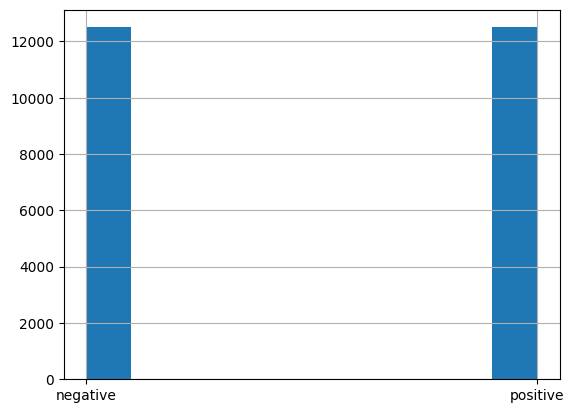

In [22]:
train_df.sentiment.hist()

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
examples_df , gold_examples_df = train_test_split(train_df, test_size=0.2, random_state=123)

In [25]:
examples_df.shape, gold_examples_df.shape

((20000, 3), (5000, 3))

In [26]:
columns = ['text', 'sentiment']
gold_examples = (gold_examples_df[columns]
                 .sample(10,random_state=34)
                 .to_json(orient='records')
                 )


In [29]:
import json

In [31]:
json.loads(gold_examples)[0]

{'text': '"A Guy Thing" may not be a classic, but it sure is a good, funny comedy. The plot focuses on Paul (Jason Lee), who wakes up the morning after his bachelor party with no memory and Becky (Julia Stiles) lying naked in his bed. Before he can figure out what happened, he rushes Becky out of his apartment because his fiance Karen (Selma Blair) is coming. After that, as you could imagine, chaos ensues.<br /><br />Almost every single scene in "A Guy Thing" delivers loud laughs. The funniest moments come from when Paul imagines what could happen if he tells Karen. Selma Blair is a truly talented comedian, and the worst thing about this film is that she goes underused. Although, she turns out to be more funny than Stiles\' character, who actually isn\'t that interesting. Of course, not every comedy is perfect.<br /><br />As I said, "A Guy Thing" is no classic, but it\'s not bad either, 7/10.',
 'sentiment': 'positive'}